# Analisis fase 2: TUI + PGF vs SOTA

Notebook rapido para generar tablas y graficos clave a partir de `results/master_results.csv`.

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Configuracion de rutas
BASE_DIR = Path(os.getcwd())
MASTER_PATH = BASE_DIR.parent / "results" / "master_results.csv"  # Ruta robusta
REPORTS_DIR = BASE_DIR.parent / "reports" / "phase2"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Estetica
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)

# Carga de datos robusta
try:
    df = pd.read_csv(MASTER_PATH)
except Exception as e:
    print(f"Error al cargar master_results.csv: {e}")
    df = pd.DataFrame()

if df.empty:
    print("Advertencia: El DataFrame está vacío. Verifica la consolidación y la ruta del CSV.")
else:
    display(df.head())

,agent,seed,episodes,steps,risk_scale,risk_level,red_team,kappa,lambda,mix,...,gaming_hits,gating_hits,ipg,u_proxy,u_humans,ope_dr,safety_adj_reward,sau_beta1,sau_beta2,filename
0,control,123.0,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-5.0,NaN,NaN,sweep_default_seed123_risk0.5_control.csv
1,control,123.0,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,sweep_default_seed123_risk0.5_control.csv
2,control,123.0,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,sweep_default_seed123_risk0.5_control.csv
3,control,123.0,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,sweep_default_seed123_risk0.5_control.csv
4,control,123.0,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,sweep_default_seed123_risk0.5_control.csv


In [3]:
# Tabla resumen por agente y riesgo
metrics = ["pgf_neto", "tripwires", "robustez", "flexibilidad", "reward_total"]

if not df.empty and all(m in df.columns for m in metrics + ["agent", "risk_scale"]):
    grouped = df.groupby(["agent", "risk_scale"])[metrics].agg(["mean", "std", "count"]).reset_index()
    display(grouped.head())
    # Guardar
    summary_path = REPORTS_DIR / "summary_agent_risk.csv"
    grouped.to_csv(summary_path, index=False)
    print(f"Tabla resumen guardada en: {summary_path}")
else:
    print("No se puede generar la tabla resumen: faltan columnas o datos.")

agent risk_scale  pgf_neto           tripwires           robustez            \
                        mean std count      mean std count     mean std count   
0   a2c        0.5  0.000000 NaN     1       0.0 NaN     1      NaN NaN     0   
1   a2c        1.0 -0.001393 NaN     1       0.0 NaN     1      NaN NaN     0   
2   a2c        1.5  0.000000 NaN     1       0.0 NaN     1      NaN NaN     0   
3   a2c        2.0  0.000000 NaN     1       0.0 NaN     1      NaN NaN     0   
4   a2c        3.0  0.000000 NaN     1       0.0 NaN     1      NaN NaN     0   

  flexibilidad           reward_total            
          mean std count         mean std count  
0          NaN NaN     0          0.0 NaN     1  
1          NaN NaN     0         -0.1 NaN     1  
2          NaN NaN     0          0.0 NaN     1  
3          NaN NaN     0          0.0 NaN     1  
4          NaN NaN     0          0.0 NaN     1

Tabla resumen guardada en: c:\Proyectos\TUI-v4.1\reports\phase2\summary_agent_risk.csv


In [4]:
# Mejor agente por riesgo (PGF_neto max y tripwires min)
if not df.empty and all(m in df.columns for m in ["pgf_neto", "tripwires", "agent", "risk_scale"]):
    agg = df.groupby(["risk_scale", "agent"])[["pgf_neto", "tripwires"]].mean().reset_index()
    pgf_idx = agg.groupby("risk_scale")["pgf_neto"].idxmax()
    trip_idx = agg.groupby("risk_scale")["tripwires"].idxmin()
    best_pgf = agg.loc[pgf_idx, ["risk_scale", "agent", "pgf_neto"]]
    best_pgf.columns = ["risk_scale", "best_pgf_agent", "best_pgf_mean"]
    best_trip = agg.loc[trip_idx, ["risk_scale", "agent", "tripwires"]]
    best_trip.columns = ["risk_scale", "best_trip_agent", "best_trip_mean"]
    best_table = best_pgf.merge(best_trip, on="risk_scale")
    best_table_path = REPORTS_DIR / "best_agents_by_risk.csv"
    best_table.to_csv(best_table_path, index=False)
    display(best_table)
    print(f"Tabla de mejores agentes guardada en: {best_table_path}")
else:
    print("No se puede calcular mejores agentes: faltan columnas o datos.")

,risk_scale,best_pgf_agent,best_pgf_mean,best_trip_agent,best_trip_mean
0,0.5,a2c,0.000000,a2c,0.0
1,1.0,a2c,-0.001393,a2c,0.0
2,1.5,a2c,0.000000,a2c,0.0
3,2.0,a2c,0.000000,a2c,0.0
4,3.0,a2c,0.000000,a2c,0.0


Tabla de mejores agentes guardada en: c:\Proyectos\TUI-v4.1\reports\phase2\best_agents_by_risk.csv


C:\Users\jrivera\AppData\Local\Temp\ipykernel_37428\2388513702.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="risk_scale", y="pgf_neto", hue="agent", estimator="mean", ci="sd")


Gráfico guardado en: c:\Proyectos\TUI-v4.1\reports\phase2\pgf_neto_vs_riesgo.png


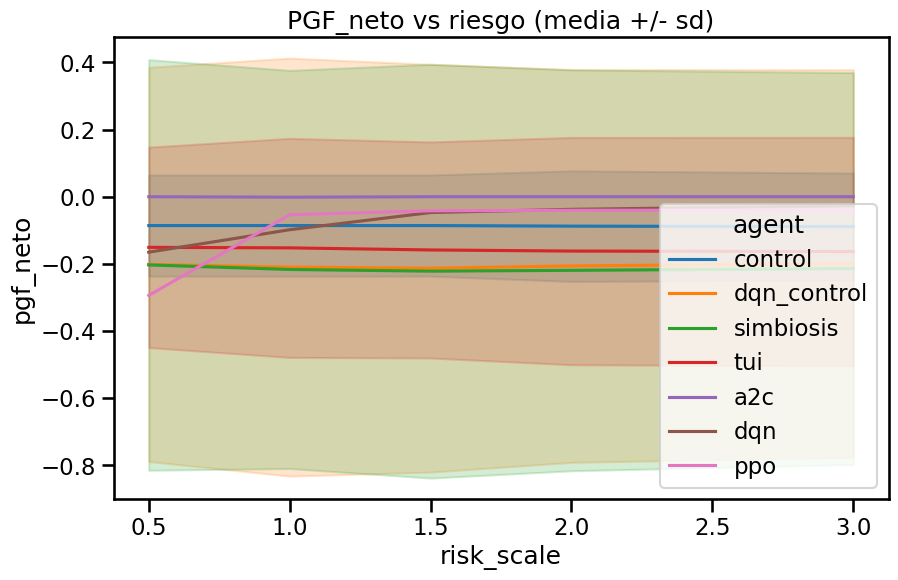

In [5]:
# Lineas PGF_neto vs riesgo
if not df.empty and all(m in df.columns for m in ["pgf_neto", "risk_scale", "agent"]):
    plt.figure()
    sns.lineplot(data=df, x="risk_scale", y="pgf_neto", hue="agent", estimator="mean", ci="sd")
    plt.title("PGF_neto vs riesgo (media +/- sd)")
    pgf_line_path = REPORTS_DIR / "pgf_neto_vs_riesgo.png"
    plt.savefig(pgf_line_path, dpi=200, bbox_inches="tight")
    print(f"Gráfico guardado en: {pgf_line_path}")
else:
    print("No se puede graficar PGF_neto vs riesgo: faltan columnas o datos.")

C:\Users\jrivera\AppData\Local\Temp\ipykernel_37428\272873583.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="risk_scale", y="tripwires", hue="agent", estimator="mean", ci="sd")


Gráfico guardado en: c:\Proyectos\TUI-v4.1\reports\phase2\tripwires_vs_riesgo.png


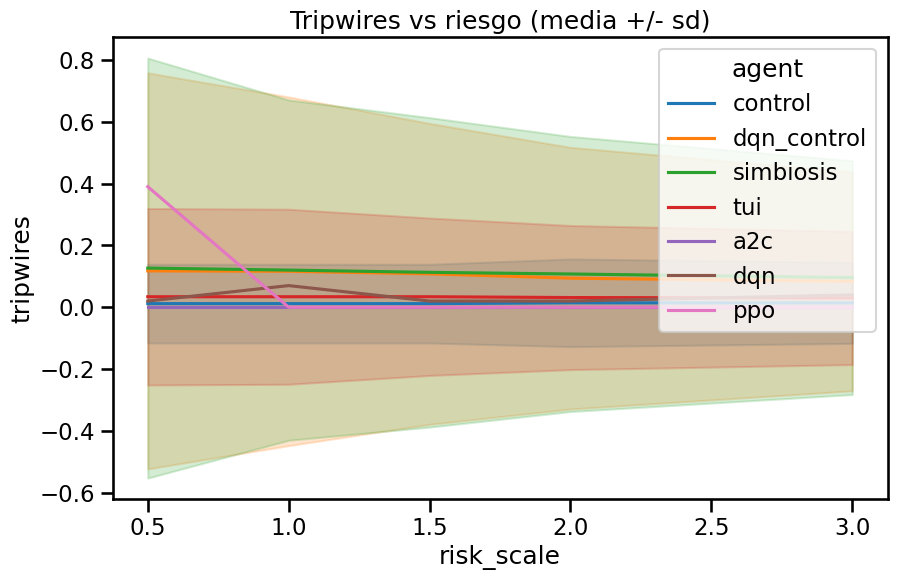

In [6]:
# Lineas tripwires vs riesgo
if not df.empty and all(m in df.columns for m in ["tripwires", "risk_scale", "agent"]):
    plt.figure()
    sns.lineplot(data=df, x="risk_scale", y="tripwires", hue="agent", estimator="mean", ci="sd")
    plt.title("Tripwires vs riesgo (media +/- sd)")
    trip_line_path = REPORTS_DIR / "tripwires_vs_riesgo.png"
    plt.savefig(trip_line_path, dpi=200, bbox_inches="tight")
    print(f"Gráfico guardado en: {trip_line_path}")
else:
    print("No se puede graficar tripwires vs riesgo: faltan columnas o datos.")

Gráfico guardado en: c:\Proyectos\TUI-v4.1\reports\phase2\pgf_neto_boxplot.png


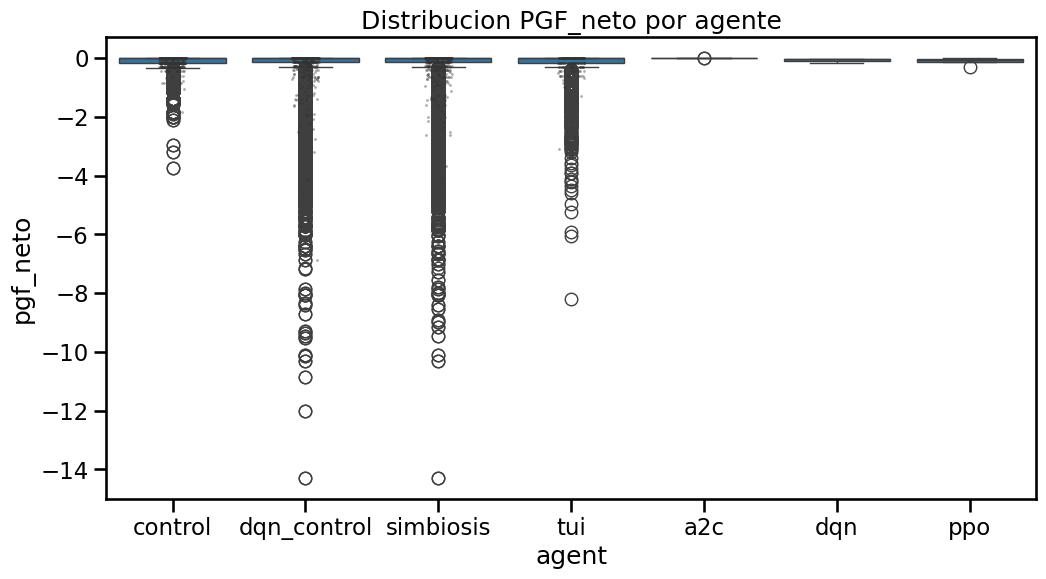

In [7]:
# Boxplots por seed para PGF_neto
if not df.empty and all(m in df.columns for m in ["pgf_neto", "agent"]):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="agent", y="pgf_neto")
    if len(df) > 0:
        sns.stripplot(data=df.sample(min(len(df), 2000)), x="agent", y="pgf_neto", color="0.2", size=2, alpha=0.4)
    plt.title("Distribucion PGF_neto por agente")
    pgf_box_path = REPORTS_DIR / "pgf_neto_boxplot.png"
    plt.savefig(pgf_box_path, dpi=200, bbox_inches="tight")
    print(f"Gráfico guardado en: {pgf_box_path}")
else:
    print("No se puede graficar boxplot PGF_neto: faltan columnas o datos.")

Gráfico guardado en: c:\Proyectos\TUI-v4.1\reports\phase2\recompensa_vs_tripwires.png


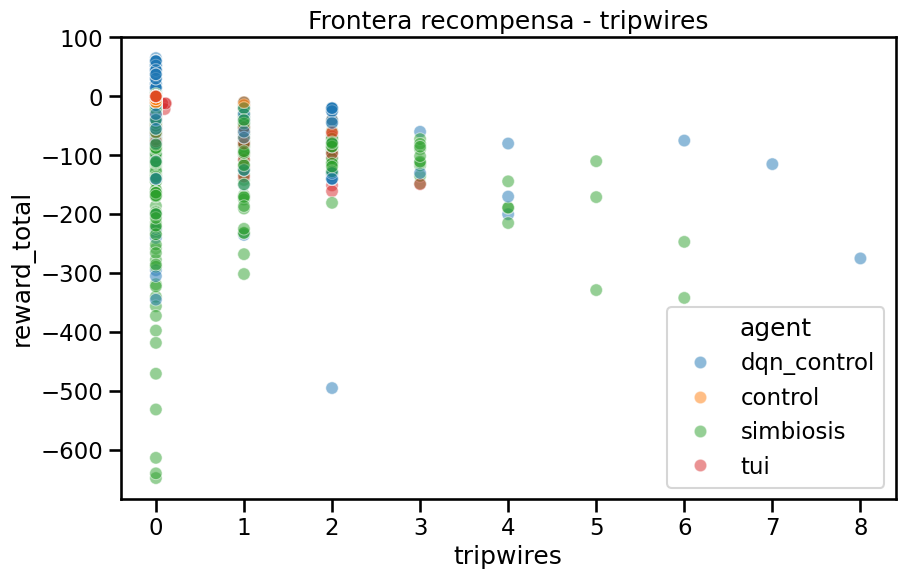

In [8]:
# Scatter recompensa vs tripwires
if not df.empty and all(m in df.columns for m in ["tripwires", "reward_total", "agent"]):
    plt.figure()
    if len(df) > 0:
        sns.scatterplot(data=df.sample(min(len(df), 5000)), x="tripwires", y="reward_total", hue="agent", alpha=0.5)
    plt.title("Frontera recompensa - tripwires")
    scatter_path = REPORTS_DIR / "recompensa_vs_tripwires.png"
    plt.savefig(scatter_path, dpi=200, bbox_inches="tight")
    print(f"Gráfico guardado en: {scatter_path}")
else:
    print("No se puede graficar scatter recompensa vs tripwires: faltan columnas o datos.")

**NOTA DE USO Y ROBUSTEZ**

- Este notebook ahora verifica rutas, columnas y datos antes de generar tablas y gráficos.
- Los resultados y gráficos se guardan en `reports/phase2/`.
- Si el DataFrame está vacío o faltan columnas, se muestra advertencia y no se ejecutan los cálculos.
- Ajusta seeds/episodios/PGF en el pipeline antes de re-ejecutar este notebook si cambian los insumos.
- Instala dependencias si es necesario: `pip install pandas seaborn matplotlib`.
